# fio DFS All-Patterns Analysis

Analyzes `rand_write / rand_read / mixed` and `seq_write / seq_read / mixed` results
across block sizes. Two configurations are compared:

- **nj32/iod8**: numjobs=32, iodepth=8 (256 total outstanding I/Os)
- **nj16/iod16**: numjobs=16, iodepth=16 (256 total outstanding I/Os)

Both configurations maintain the same total queue depth (nj × iodepth = 256), but differ
in how parallelism is distributed: more jobs vs. deeper per-job queue. The `prefill` job
is excluded from all analysis.

In [1]:
import json
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

RESULTS_DIR = Path(".")

In [2]:
def parse_file(fpath):
    m = re.search(r"fio_bs(\S+?)_nj(\d+)_iod(\d+)_", Path(fpath).name)
    bs, nj, iod = m.group(1), int(m.group(2)), int(m.group(3))

    with open(fpath) as f:
        d = json.load(f)

    rows = []
    for job in d["jobs"]:
        name = job["jobname"]
        if name == "prefill":
            continue

        def ms(v): return v / 1e6

        if "mixed" in job:
            mx = job["mixed"]
            bw_GiBs     = mx["bw"] / 1024 / 1024
            iops        = mx["iops"]
            lat_max_ms  = ms(mx["lat_ns"]["max"])
            lat_mean_ms = ms(mx["lat_ns"]["mean"])
        else:
            r = job["read"]
            w = job["write"]
            has_read  = r["total_ios"] > 0
            has_write = w["total_ios"] > 0

            bw_GiBs = (r["bw"] * has_read + w["bw"] * has_write) / 1024 / 1024
            iops    =  r["iops"] * has_read + w["iops"] * has_write

            candidates = []
            if has_read:  candidates.append(r["lat_ns"]["max"])
            if has_write: candidates.append(w["lat_ns"]["max"])
            lat_max_ms = ms(max(candidates)) if candidates else 0

            mean_num = (r["lat_ns"]["mean"] * r["total_ios"] * has_read +
                        w["lat_ns"]["mean"] * w["total_ios"] * has_write)
            mean_den = r["total_ios"] * has_read + w["total_ios"] * has_write
            lat_mean_ms = ms(mean_num / mean_den) if mean_den > 0 else 0

        rows.append(dict(
            block_size  = bs,
            numjobs     = nj,
            iodepth     = iod,
            config      = f"nj{nj}/iod{iod}",
            pattern     = name,
            bw_GiBs     = bw_GiBs,
            iops        = iops,
            lat_mean_ms = lat_mean_ms,
            lat_max_ms  = lat_max_ms,
        ))
    return rows


all_rows = []
for fpath in sorted(RESULTS_DIR.glob("*.json")):
    all_rows.extend(parse_file(fpath))

BS_ORDER = ["4k", "16k", "1m", "2m", "4m"]
PATTERN_ORDER = [
    "rand_read", "rand_readH", "rand_readB", "rand_writeH", "rand_write",
    "seq_read",  "seq_readH",  "seq_readB",  "seq_writeH", "seq_write"
]
CONFIGS = ["nj32/iod8", "nj16/iod16"]

df = pd.DataFrame(all_rows)
df["block_size"] = pd.Categorical(df["block_size"], categories=BS_ORDER, ordered=True)
df["pattern"]    = pd.Categorical(df["pattern"],    categories=PATTERN_ORDER, ordered=True)
df = df.sort_values(["config", "block_size", "pattern"]).reset_index(drop=True)

print(f"Loaded {len(df)} jobs from {df['config'].nunique()} config(s) × {df['block_size'].nunique()} block size(s)")
for cfg in CONFIGS:
    n = len(df[df["config"] == cfg])
    print(f"  {cfg}: {n} jobs")
df

Loaded 100 jobs from 2 config(s) × 5 block size(s)
  nj32/iod8: 50 jobs
  nj16/iod16: 50 jobs


,block_size,numjobs,iodepth,config,pattern,bw_GiBs,iops,lat_mean_ms,lat_max_ms
0,4k,16,16,nj16/iod16,rand_read,2.717772,7.124479e+05,0.358873,41.688196
1,4k,16,16,nj16/iod16,rand_readH,3.946706,1.034605e+06,0.246886,113.016345
2,4k,16,16,nj16/iod16,rand_readB,3.790335,9.936136e+05,0.257014,48.433721
3,4k,16,16,nj16/iod16,rand_writeH,5.119674,1.342092e+06,0.190039,44.962336
4,4k,16,16,nj16/iod16,rand_write,5.891620,1.544453e+06,0.164991,57.499589
...,...,...,...,...,...,...,...,...,...
95,4m,32,8,nj32/iod8,seq_read,3.719929,9.523019e+02,267.358874,1689.437157
96,4m,32,8,nj32/iod8,seq_readH,4.344652,1.112231e+03,228.768751,2054.593795
97,4m,32,8,nj32/iod8,seq_readB,8.532248,2.184256e+03,116.685110,565.761539
98,4m,32,8,nj32/iod8,seq_writeH,12.140118,3.107870e+03,81.944971,293.392045


## Mean/Max Latency (ms)

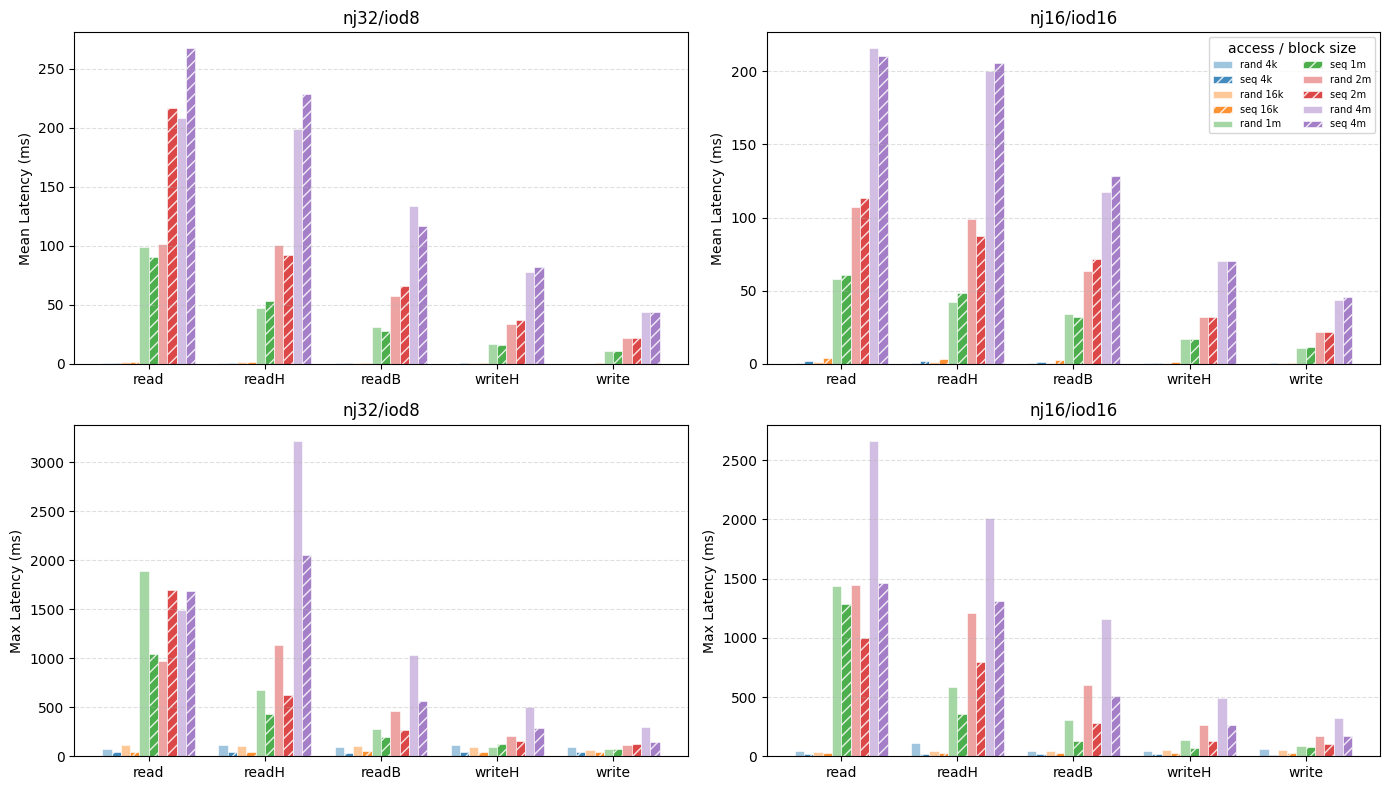

In [3]:
BASE_OPS = ["read", "readH", "readB", "writeH", "write"]
ACCESS   = ["rand", "seq"]
_hatches = {"rand": "", "seq": "///"}

def plot_metric(ax, col, cfg):
    df_sub  = df[df["config"] == cfg]
    bs_l    = sorted(df_sub["block_size"].unique(), key=lambda b: BS_ORDER.index(b))
    combos  = [(acc, bs) for bs in bs_l for acc in ACCESS]
    n       = len(combos)
    bar_w   = 0.8 / n
    x       = list(range(len(BASE_OPS)))
    offsets = [(i - (n - 1) / 2) * bar_w for i in range(n)]
    clrs    = plt.cm.tab10.colors

    sub_all = df_sub.set_index(["block_size", "pattern"])[col]
    for i, (acc, bs) in enumerate(combos):
        vals     = [sub_all.get((bs, f"{acc}_{op}"), 0) for op in BASE_OPS]
        base_clr = clrs[bs_l.index(bs)]
        bar_clr  = tuple(c * 0.5 + 0.5 for c in base_clr[:3]) if acc == "rand" else base_clr
        ax.bar([xi + offsets[i] for xi in x], vals, bar_w,
               label=f"{acc} {bs}",
               color=bar_clr,
               hatch=_hatches[acc], alpha=0.85, edgecolor="white", linewidth=0.5)
    return x, bs_l

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for row_idx, (col, ylabel) in enumerate([
    ("lat_mean_ms", "Mean Latency (ms)"),
    ("lat_max_ms",  "Max Latency (ms)"),
]):
    for col_idx, cfg in enumerate(CONFIGS):
        ax = axes[row_idx][col_idx]
        x_ticks, _ = plot_metric(ax, col, cfg)
        ax.set_xticks(x_ticks)
        ax.set_xticklabels(BASE_OPS)
        ax.set_ylabel(ylabel)
        ax.set_title(cfg)
        if row_idx == 0 and col_idx == 1:
            ax.legend(title="access / block size", loc="upper right", ncol=2, fontsize=7)
        ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "latency-all-pattern.pdf", dpi=150)
plt.show()

## Bandwidth (GiB/s)

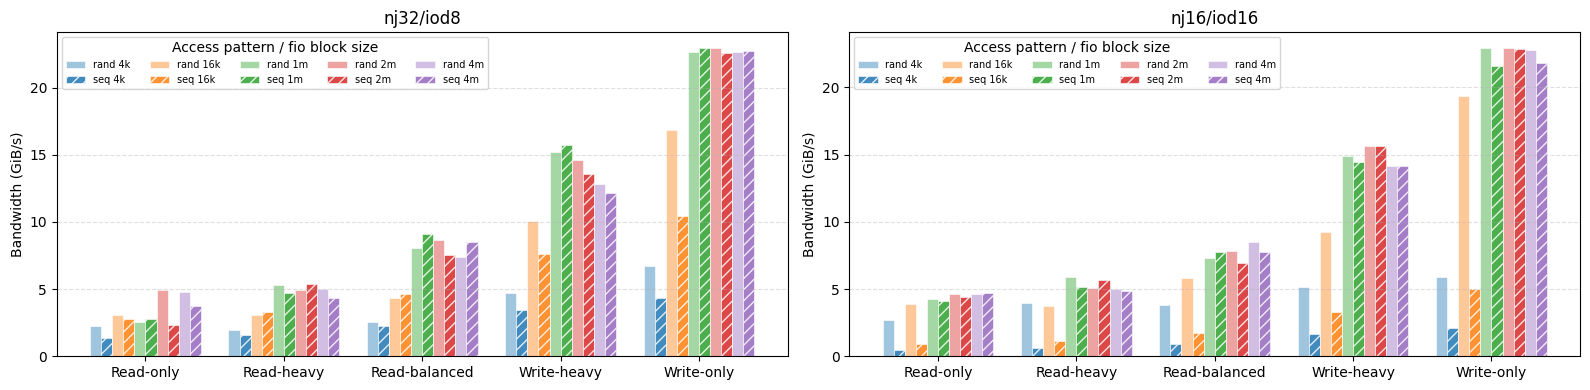

In [10]:
OP_LABELS = ["Read-only", "Read-heavy", "Read-balanced", "Write-heavy", "Write-only"]

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
for ax, cfg in zip(axes, CONFIGS):
    x_ticks, _ = plot_metric(ax, "bw_GiBs", cfg)
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(OP_LABELS, ha="center")
    ax.set_ylabel("Bandwidth (GiB/s)")
    ax.set_title(cfg)
    ax.legend(title="Access pattern / fio block size", loc="upper left", ncol=5, fontsize=7)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "bw-all-pattern.pdf", dpi=150)
plt.show()

## CPU Usage (usr / sys)

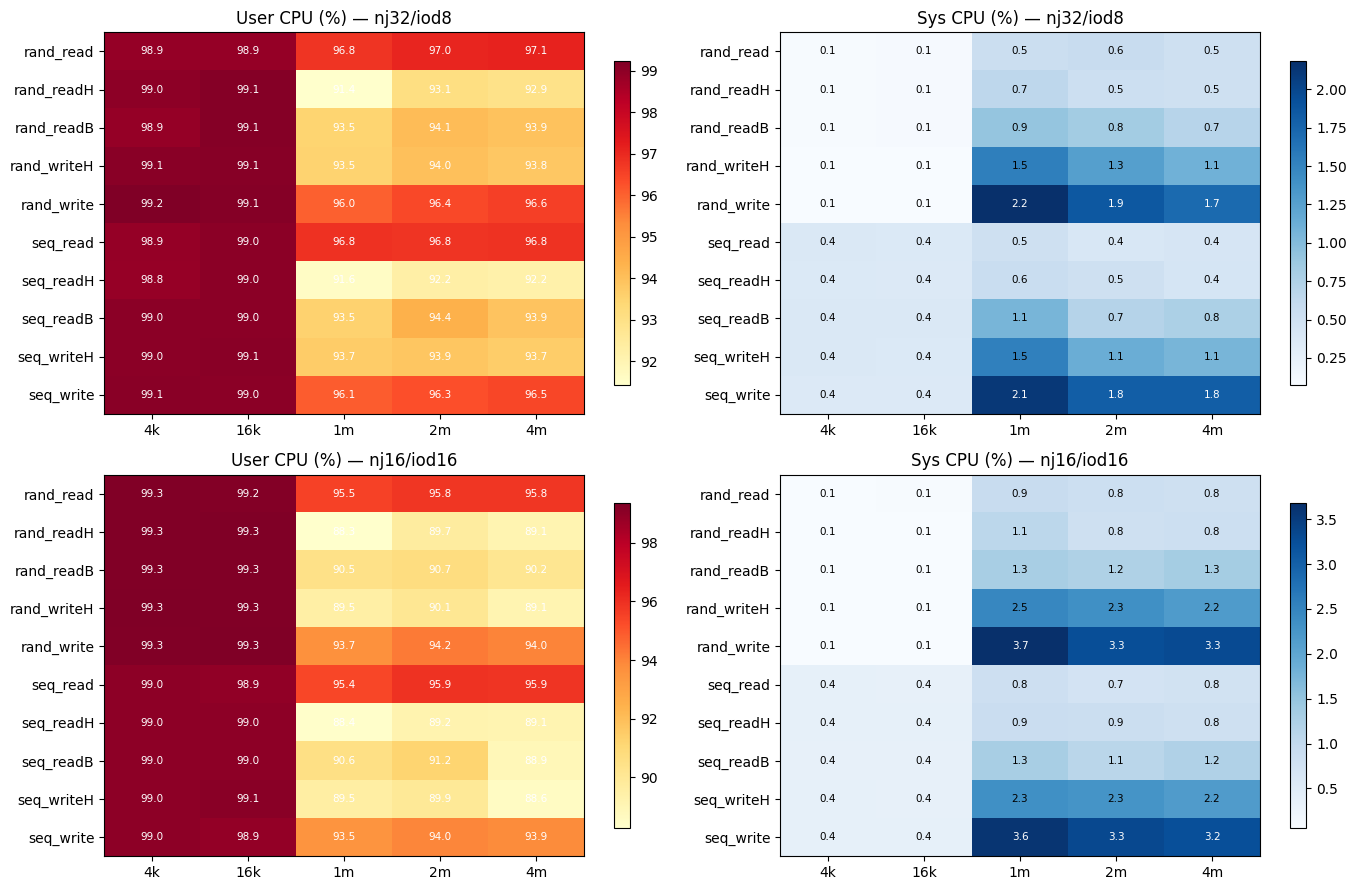

In [5]:
cpu_rows = []
for fpath in sorted(RESULTS_DIR.glob("*.json")):
    m = re.search(r"fio_bs(\S+?)_nj(\d+)_iod(\d+)_", Path(fpath).name)
    bs, nj, iod = m.group(1), int(m.group(2)), int(m.group(3))
    cfg = f"nj{nj}/iod{iod}"
    with open(fpath) as f:
        d = json.load(f)
    for job in d["jobs"]:
        if job["jobname"] == "prefill":
            continue
        cpu_rows.append(dict(
            block_size = bs,
            config     = cfg,
            pattern    = job["jobname"],
            usr_cpu    = job["usr_cpu"],
            sys_cpu    = job["sys_cpu"],
        ))

df_cpu = pd.DataFrame(cpu_rows)
df_cpu["block_size"] = pd.Categorical(df_cpu["block_size"], categories=BS_ORDER, ordered=True)
df_cpu["pattern"]    = pd.Categorical(df_cpu["pattern"],    categories=PATTERN_ORDER, ordered=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for row_idx, cfg in enumerate(CONFIGS):
    df_c = df_cpu[df_cpu["config"] == cfg]
    pivot_usr = df_c.pivot(index="pattern", columns="block_size", values="usr_cpu")
    pivot_sys = df_c.pivot(index="pattern", columns="block_size", values="sys_cpu")
    for col_idx, (pivot, title, cmap) in enumerate([
        (pivot_usr, f"User CPU (%) — {cfg}", "YlOrRd"),
        (pivot_sys, f"Sys CPU (%) — {cfg}",  "Blues"),
    ]):
        ax = axes[row_idx][col_idx]
        im = ax.imshow(pivot.values, aspect="auto", cmap=cmap,
                       vmin=pivot.values.min(), vmax=pivot.values.max())
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels(pivot.columns)
        ax.set_yticks(range(len(pivot.index)))
        ax.set_yticklabels(pivot.index)
        ax.set_title(title)
        plt.colorbar(im, ax=ax, shrink=0.85)
        for i in range(len(pivot.index)):
            for j in range(len(pivot.columns)):
                ax.text(j, i, f"{pivot.values[i, j]:.1f}",
                        ha="center", va="center", fontsize=7.5,
                        color="black" if pivot.values[i, j] < pivot.values.max() * 0.75 else "white")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "cpu_usage.pdf", dpi=150)
plt.show()

## Comparison: nj16/iod16 vs nj32/iod8

Both configurations use 256 total outstanding I/Os (nj × iodepth = 32×8 = 16×16).
The heatmaps show the **percentage change** when switching from nj32/iod8 to nj16/iod16.
- **Bandwidth**: green = nj16/iod16 is faster; red = nj32/iod8 is faster.
- **Mean latency**: green = nj16/iod16 has lower latency; red = nj16/iod16 has higher latency.

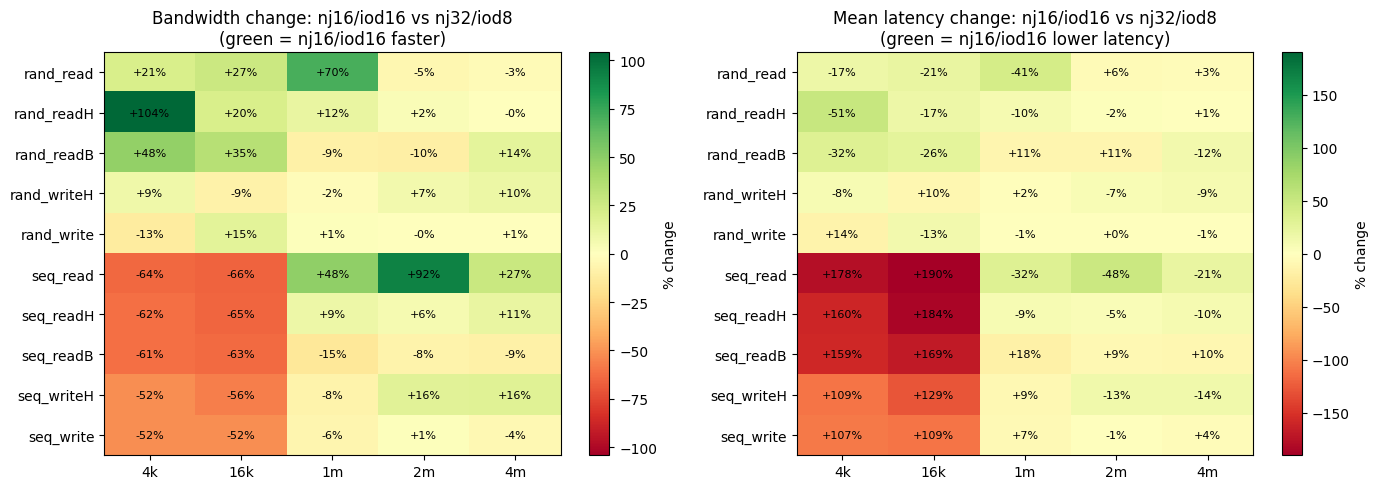

In [6]:
def make_pivot(col, cfg):
    return (df[df["config"] == cfg]
            .pivot(index="pattern", columns="block_size", values=col)
            .reindex(PATTERN_ORDER))

bw_32_8   = make_pivot("bw_GiBs",     "nj32/iod8")
bw_16_16  = make_pivot("bw_GiBs",     "nj16/iod16")
lat_32_8  = make_pivot("lat_mean_ms", "nj32/iod8")
lat_16_16 = make_pivot("lat_mean_ms", "nj16/iod16")

bw_ratio  = (bw_16_16  / bw_32_8  - 1) * 100   # positive = nj16/iod16 faster
lat_ratio = (lat_16_16 / lat_32_8 - 1) * 100   # positive = nj16/iod16 slower

def draw_ratio_heatmap(ax, mat, title, cmap, cb_label, invert_sign=False):
    vals = mat.values
    finite = vals[~(vals != vals)]  # exclude NaN
    if len(finite) == 0:
        return
    vmax = max(abs(vals[~(vals != vals)].min() if len(finite) else 0),
               abs(vals[~(vals != vals)].max() if len(finite) else 0))
    vmax = max(vmax, 1.0)
    sign = -1 if invert_sign else 1
    im = ax.imshow(sign * vals, aspect="auto", cmap=cmap, vmin=-vmax, vmax=vmax)
    ax.set_xticks(range(len(mat.columns)))
    ax.set_xticklabels(mat.columns)
    ax.set_yticks(range(len(mat.index)))
    ax.set_yticklabels(mat.index)
    ax.set_title(title)
    plt.colorbar(im, ax=ax, label=cb_label)
    for i in range(len(mat.index)):
        for j in range(len(mat.columns)):
            v = vals[i, j]
            if v == v:  # not NaN
                ax.text(j, i, f"{v:+.0f}%", ha="center", va="center",
                        fontsize=8, color="black")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

draw_ratio_heatmap(
    axes[0], bw_ratio,
    "Bandwidth change: nj16/iod16 vs nj32/iod8\n(green = nj16/iod16 faster)",
    "RdYlGn", "% change"
)
draw_ratio_heatmap(
    axes[1], lat_ratio,
    "Mean latency change: nj16/iod16 vs nj32/iod8\n(green = nj16/iod16 lower latency)",
    "RdYlGn", "% change",
    invert_sign=True   # negate so negative (lower lat) maps to green end
)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "config_comparison_ratio.pdf", dpi=150)
plt.show()

## Key Findings

**Setup:** fio via DAOS DFS API, two configurations with identical total queue depth (256):
- **nj32/iod8**: numjobs=32, iodepth=8 — more parallel jobs, shallower per-job queue.
- **nj16/iod16**: numjobs=16, iodepth=16 — fewer jobs, deeper per-job queue.

Block sizes 4k–4m; patterns: `read`, `readH` (read-heavy mixed), `readB` (read-biased mixed),
`writeH` (write-heavy mixed), `write`.

---

### 1. Write throughput saturates at ~22–23 GiB/s for large block sizes (both configs)
Both `rand_write` and `seq_write` reach ~22–23 GiB/s at ≥1 MiB block sizes in both
configurations, with essentially no difference between them. DAOS VOS log-append absorbs
random writes efficiently once I/O size is large enough to saturate the network, making
job count vs. iodepth irrelevant.

### 2. nj32/iod8 dominates sequential I/O at small block sizes
At 4k: `seq_read` 1.39 (nj32) vs. 0.50 (nj16) GiB/s (−64%); `seq_write` 4.36 vs. 2.11 GiB/s (−52%).
At 16k: `seq_read` 2.74 vs. 0.94 GiB/s (−66%); `seq_write` 10.47 vs. 5.03 GiB/s (−52%).
More parallel jobs provide better server-side dispatch coverage at small block sizes,
where each I/O is short and the bottleneck is request throughput, not per-request pipeline depth.

### 3. nj16/iod16 improves large-block read throughput significantly
At 1m: `seq_read` 4.10 vs. 2.76 GiB/s (+48%); `rand_read` 4.29 vs. 2.52 GiB/s (+70%).
At 2m: `seq_read` 4.42 vs. 2.29 GiB/s (+92%).
With large blocks, deeper per-job iodepth (16 vs. 8) keeps more in-flight I/Os per job,
better saturating the server-side fetch pipeline. This reverses the small-block ranking.

### 4. Random write at 16k favors nj16/iod16; small blocks favor nj32/iod8
At 16k: `rand_write` 19.34 (nj16) vs. 16.83 (nj32) GiB/s (+15%).
At 4k: `rand_write` 5.89 (nj16) vs. 6.73 (nj32) GiB/s (−13%).
The crossover reflects the same pipeline depth vs. dispatch parallelism trade-off.

### 5. Mixed patterns (readB > readH > pure read) holds for both configs
At 1m nj16/iod16: `rand_readB` 7.32, `rand_readH` 5.93, `rand_read` 4.29 GiB/s.
The write-component warm-up effect on DAOS server DRAM cache is present regardless of
job/iodepth split.

### 6. Random write outperforms sequential write at small block sizes (nj32/iod8)
At 4k: `rand_write` 6.7 GiB/s vs. `seq_write` 4.4 GiB/s (+52%).
At 16k: `rand_write` 16.8 GiB/s vs. `seq_write` 10.5 GiB/s (+60%).
Random offsets spread load across more server shards. This gap narrows for nj16/iod16
(rand_write 19.3 vs. seq_write 5.0 GiB/s at 16k — a much larger rand/seq gap, driven
by the severe sequential degradation in the low-nj regime).

### 7. Read latency at large blocks is lower with nj16/iod16
At 1m: `rand_read` mean lat 58 ms (nj16) vs. 99 ms (nj32) (−41%).
At 2m: `seq_read` mean lat 113 ms (nj16) vs. 217 ms (nj32) (−48%).
The deeper iodepth per job reduces queuing delay per request when fewer jobs compete
for the server pipeline at large transfer sizes.

### 8. Small-block sequential latency is 2–3× worse for nj16/iod16
At 4k: `seq_read` mean lat 1.9 ms (nj16) vs. 0.7 ms (nj32) (+178%).
At 16k: `seq_read` mean lat 4.1 ms (nj16) vs. 1.4 ms (nj32) (+190%).
Consistent with the throughput degradation: fewer concurrent sequential streams lead to
underutilization and higher per-request latency at the server.

## Conclusion

The two configurations — nj32/iod8 and nj16/iod16 — maintain the same total queue depth
(256 outstanding I/Os) but distribute parallelism differently: more jobs vs. deeper per-job
queue. The results show a clear block-size-dependent crossover with **no universally better
setting**.

### Small blocks (4k–16k): more jobs (nj32/iod8) wins
Sequential read and write performance degrades by 50–66% when switching to nj16/iod16 at
small block sizes. The bottleneck at small blocks is **RPC throughput** — how many
independent requests reach the server per second. More parallel jobs generate more
concurrent, uncorrelated requests, keeping server-side dispatch queues full. A deeper
per-job iodepth cannot compensate because sequential streams carry ordering constraints
that limit effective pipelining within a single job.

### Large blocks (≥1m): deeper queue (nj16/iod16) wins for reads
At large block sizes the bottleneck shifts to **per-connection pipeline saturation**: each
transfer must keep enough data in flight to fully utilize the network path. nj16/iod16
achieves this more effectively, recovering +48–92% on sequential reads and +70% on random
reads at 1–2 MiB. The deeper per-job iodepth (16 vs. 8) keeps more bytes in flight per
job while reducing inter-job contention at the server.

### Writes are configuration-insensitive at large blocks
Both configurations converge at ~22–23 GiB/s for writes at ≥1 MiB. DAOS VOS's
log-structured append path absorbs writes regardless of how the total queue depth is split
between jobs and iodepth, once the transfer size is large enough to saturate the network.

### Crossover and practical implications
The read performance crossover falls between 16k and 1m. For **large-block (≥1m)
read-heavy** workloads, nj16/iod16 is the better choice. For **small-block or
sequential** workloads, nj32/iod8 is preferable. Write-dominated workloads at large blocks
are insensitive to either setting. Mixed HPC workloads spanning a wide range of access
sizes have no single optimal configuration — the nj/iodepth split should be tuned to
the dominant block size of the application.